In [4]:
# ============================================================
# Notebook: Generate figures for the report
# Comments are in English (as requested).
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data_loader, models, evaluation

# ----------------------------
# Paths & reproducibility
# ----------------------------

TRAIN_PATH = "data/train.csv"
TEST_PATH  = "data/test.csv"

FIG_DIR = "results/figures"
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


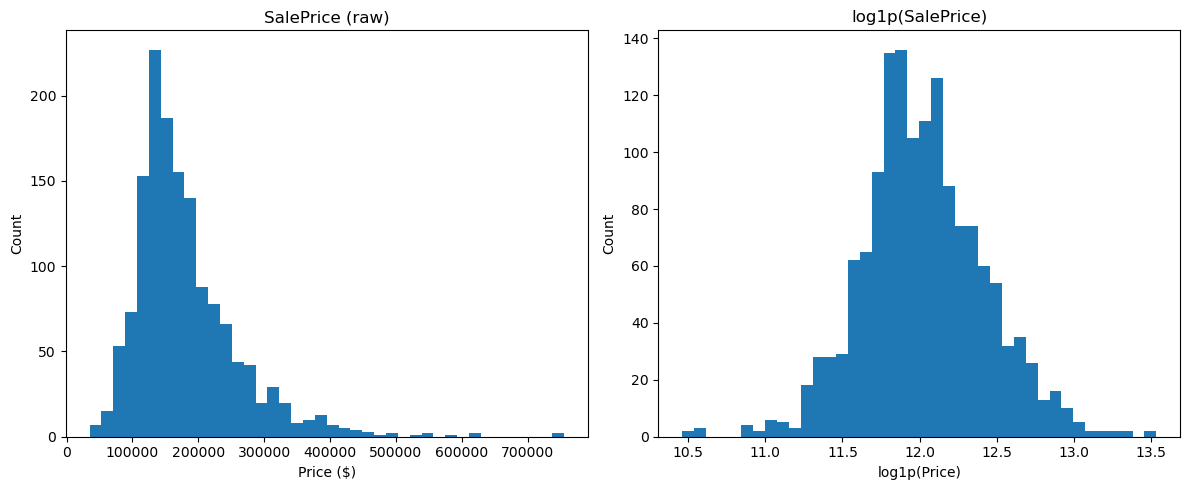

Saved: results/figures\fig1_saleprice_hist_before_after_log.png


In [7]:
# ----------------------------
# Figure 1: SalePrice distribution (raw vs log1p)
# ----------------------------

# Load raw training data for the distribution figure
train_df = pd.read_csv(TRAIN_PATH)

# Apply the same outlier handling as in src/data_loader.py for consistency
if "Id" in train_df.columns:
    train_df = train_df.drop(columns="Id")

train_df = train_df.drop(train_df[(train_df["GrLivArea"] > 4000) & (train_df["SalePrice"] < 300000)].index)
if "TotalBsmtSF" in train_df.columns:
    train_df = train_df.drop(train_df[train_df["TotalBsmtSF"] > 6000].index)

saleprice = train_df["SalePrice"].astype(float)
saleprice_log = np.log1p(saleprice)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(saleprice, bins=40)
plt.title("SalePrice (raw)")
plt.xlabel("Price ($)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(saleprice_log, bins=40)
plt.title("log1p(SalePrice)")
plt.xlabel("log1p(Price)")
plt.ylabel("Count")

plt.tight_layout()
outpath = os.path.join(FIG_DIR, "fig1_saleprice_hist_before_after_log.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)

In [9]:
# ----------------------------
# Train models (same as main.py logic)
# ----------------------------

X_train, X_val, y_train, y_val, X_test = data_loader.load_data(
    train_path=TRAIN_PATH,
    test_path=TEST_PATH,
    log_target=True
)

linear_model = models.train_linear_model(X_train, y_train)
ridge_model  = models.train_ridge_model(X_train, y_train)
lasso_model  = models.train_lasso_model(X_train, y_train)
rf_model     = models.train_rf_model(X_train, y_train)
gb_model     = models.train_gb_model(X_train, y_train)

models_list = [
    ("Linear Regression", linear_model),
    ("Ridge Regression", ridge_model),
    ("Lasso Regression", lasso_model),
    ("Random Forest", rf_model),
    ("Gradient Boosting", gb_model),
]

,r2,rmse,mae
Model,,,
Linear Regression,0.914083,21784.883776,15453.932420
Ridge Regression,0.927327,20035.665684,14508.620894
Lasso Regression,0.932616,19292.817201,14032.522663
Random Forest,0.894709,24116.356002,16518.973212
Gradient Boosting,0.925165,20331.490821,14891.578718


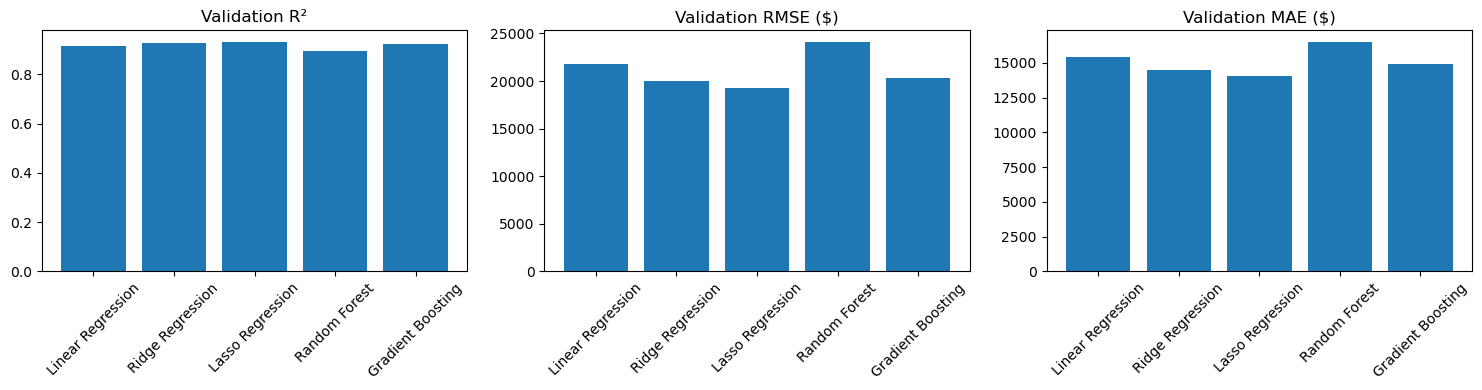

Saved: results/figures\fig4_validation_metrics_bar_chart.png


In [10]:
# ----------------------------
# Figure 2: Validation metrics comparison
# ----------------------------

val_rows = []
for name, m in models_list:
    scores = evaluation.evaluate_model(m, X_val, y_val)
    val_rows.append({"Model": name, **scores})

val_df = pd.DataFrame(val_rows).set_index("Model")
display(val_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# R2 (higher is better)
axes[0].bar(val_df.index, val_df["r2"])
axes[0].set_title("Validation R²")
axes[0].tick_params(axis="x", rotation=45)

# RMSE (lower is better)
axes[1].bar(val_df.index, val_df["rmse"])
axes[1].set_title("Validation RMSE ($)")
axes[1].tick_params(axis="x", rotation=45)

# MAE (lower is better)
axes[2].bar(val_df.index, val_df["mae"])
axes[2].set_title("Validation MAE ($)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
outpath = os.path.join(FIG_DIR, "fig4_validation_metrics_bar_chart.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)

,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std
Model,,,,,,
Linear Regression,0.889102,0.016132,23256.129334,1204.434042,15178.013300,697.180720
Ridge Regression,0.915258,0.010841,20393.775908,2394.185402,13615.444475,970.177205
Lasso Regression,0.913446,0.016305,20573.199504,2602.320761,13697.263774,819.466119
Random Forest,0.871845,0.022121,28380.539059,3383.162501,17525.630176,1715.461603
Gradient Boosting,0.898120,0.016964,24392.450936,3790.315662,15189.892751,1487.825833


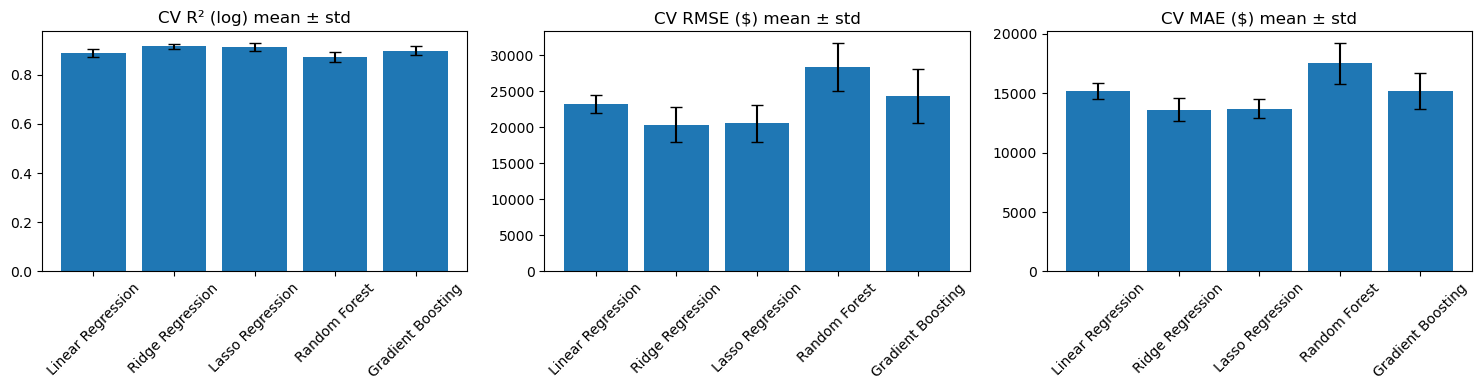

Saved: results/figures\fig5_cross_validation_mean_std.png


In [11]:
# ----------------------------
# Figure 3: Cross-validation mean ± std comparison
# ----------------------------

cv_rows = []
for name, m in models_list:
    cv = evaluation.cross_validate_model(m, X_train, y_train, cv=5)
    cv_rows.append({"Model": name, **cv})

cv_df = pd.DataFrame(cv_rows).set_index("Model")
display(cv_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# R2(log) mean ± std
axes[0].bar(cv_df.index, cv_df["r2_mean"], yerr=cv_df["r2_std"], capsize=4)
axes[0].set_title("CV R² (log) mean ± std")
axes[0].tick_params(axis="x", rotation=45)

# RMSE mean ± std
axes[1].bar(cv_df.index, cv_df["rmse_mean"], yerr=cv_df["rmse_std"], capsize=4)
axes[1].set_title("CV RMSE ($) mean ± std")
axes[1].tick_params(axis="x", rotation=45)

# MAE mean ± std
axes[2].bar(cv_df.index, cv_df["mae_mean"], yerr=cv_df["mae_std"], capsize=4)
axes[2].set_title("CV MAE ($) mean ± std")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
outpath = os.path.join(FIG_DIR, "fig5_cross_validation_mean_std.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)

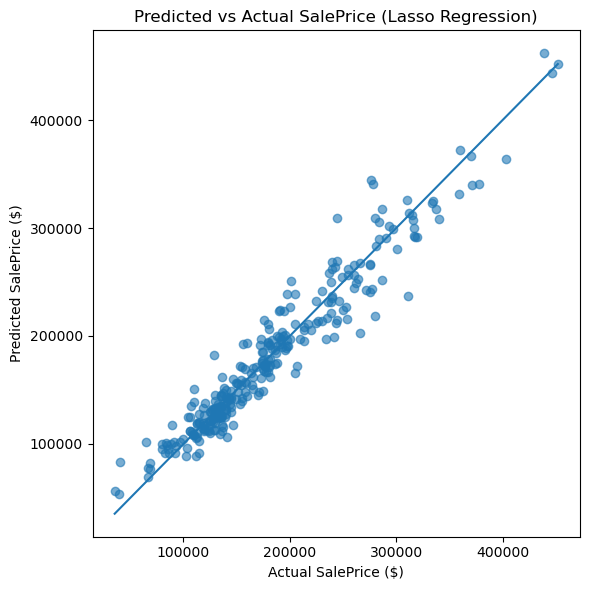

Best model: Lasso Regression
Saved: results/figures\fig6_predicted_vs_actual_scatter.png


In [12]:
# ----------------------------
# Figure 4: Predicted vs actual (best model on validation RMSE)
# ----------------------------

# Select best model by lowest validation RMSE
best_name = val_df["rmse"].idxmin()
best_model = dict(models_list)[best_name]

# Predict in log-space and convert back to dollars
y_pred_log = best_model.predict(X_val)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_val)

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()])  # diagonal reference
plt.title(f"Predicted vs Actual SalePrice ({best_name})")
plt.xlabel("Actual SalePrice ($)")
plt.ylabel("Predicted SalePrice ($)")
plt.tight_layout()

outpath = os.path.join(FIG_DIR, "fig6_predicted_vs_actual_scatter.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Best model:", best_name)
print("Saved:", outpath)

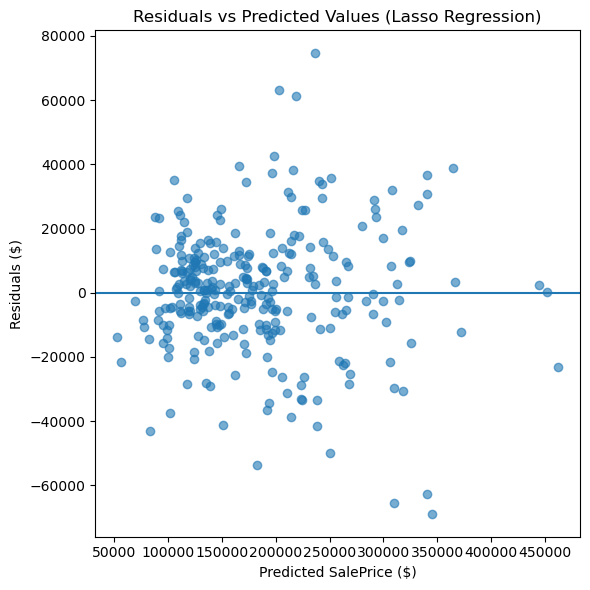

Saved: results/figures\fig8_residuals_vs_predicted.png


In [14]:
# ----------------------------
# Figure 5: Residuals vs Predicted values (best model)
# ----------------------------

# Residuals in dollars
residuals = y_true - y_pred

plt.figure(figsize=(6, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0)  # reference line
plt.xlabel("Predicted SalePrice ($)")
plt.ylabel("Residuals ($)")
plt.title(f"Residuals vs Predicted Values ({best_name})")
plt.tight_layout()

outpath = os.path.join(FIG_DIR, "fig8_residuals_vs_predicted.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)

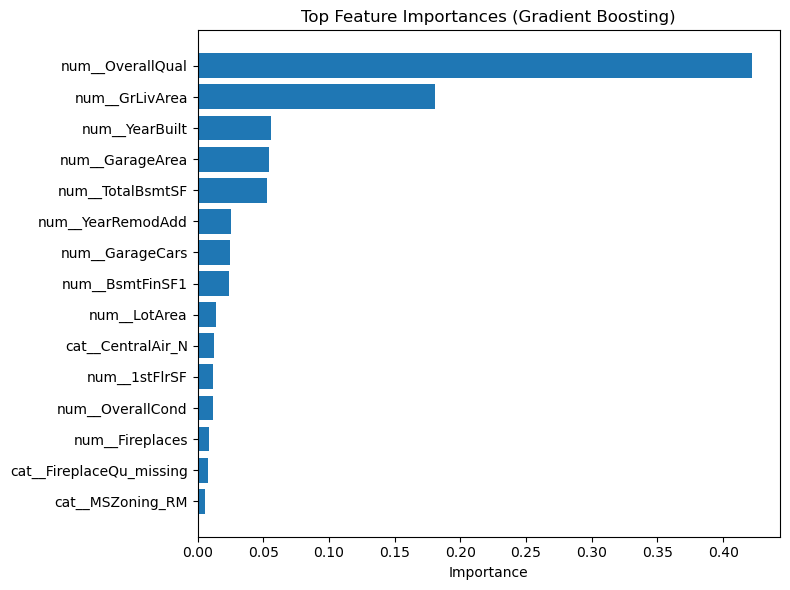

Saved: results/figures\fig7_feature_importance_gradient_boosting.png


In [13]:
# ----------------------------
# Figure 6: Feature importance (tree-based model)
# ----------------------------

def plot_feature_importance(pipeline_model, title, n_top=15, filename="fig7_feature_importance.png"):
    # Extract feature names from the preprocessor
    pre = pipeline_model.named_steps["preprocessor"]
    feat_names = pre.get_feature_names_out()

    # Extract estimator
    est = pipeline_model.named_steps["model"]

    if not hasattr(est, "feature_importances_"):
        raise ValueError("This model does not expose feature_importances_.")

    imps = est.feature_importances_
    order = np.argsort(imps)[::-1][:n_top]

    top_names = feat_names[order]
    top_imps = imps[order]

    plt.figure(figsize=(8, 6))
    plt.barh(top_names[::-1], top_imps[::-1])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()

    outpath = os.path.join(FIG_DIR, filename)
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)

# Choose Gradient Boosting (often better than RF in your results)
plot_feature_importance(
    gb_model,
    title="Top Feature Importances (Gradient Boosting)",
    n_top=15,
    filename="fig7_feature_importance_gradient_boosting.png"
)